In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/train.csv')

In [2]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
print(df['Title'].value_counts())

Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: Title, dtype: int64


In [3]:
df['Title'] = df['Title'].replace(['Dr', 'Rev', 'Major', 'Col', 'Countess', 'Capt', 'Sir', 'Lady', 'Don', 'Jonkheer'], 'Rare')
df['Title'] = df['Title'].replace(['Ms'], 'Miss')
df['Title'] = df['Title'].replace(['Mlle'], 'Miss')
df['Title'] = df['Title'].replace(['Mme'], 'Mrs')

print(df['Title'].value_counts())

Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: Title, dtype: int64


In [4]:
median_per_title = df.groupby('Title')['Age'].median()
print(median_per_title)

Title
Master     3.5
Miss      21.0
Mr        30.0
Mrs       35.0
Rare      48.5
Name: Age, dtype: float64


In [5]:
df['Age'] = df['Age'].fillna(df.groupby('Title')['Age'].transform('median'))
print(df['Age'].isnull().sum())

0


In [6]:
df['Title'] = df['Title'].map({'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4})
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

df['HasCabin'] = df['Cabin'].notnull().astype(int)

In [7]:
# Deck from Cabin
df['Deck'] = df['Cabin'].apply(lambda x: str(x)[0] if pd.notnull(x) else 'U')

# One rich man hid himself in dataset and has Cabin val T which indicates that he played hide and seek in the tank
deck_mapping = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7, "T": 8, "U": 9}
df['Deck'] = df['Deck'].map(deck_mapping)

df['FareBin'] = pd.qcut(df['Fare'], 5, labels=False)

df['AgeClass'] = df['Age'] * df['Pclass']


In [8]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'HasCabin', 'Deck', 'FareBin', 'AgeClass']

X = df[features]
y = df['Survived']

In [9]:
import xgboost as xgb
from sklearn.model_selection import cross_val_score

model_xgb = xgb.XGBClassifier(
    max_depth=3,
    learning_rate=0.1,
    n_estimators=100,
    random_state=42,
)

scores_xgb = cross_val_score(model_xgb, X, y, cv=5, scoring='accuracy')

print(f'Cross-validated accuracy scores (XGBoost): {scores_xgb}')
print(f'Mean accuracy (XGBoost): {scores_xgb.mean() * 100}%')

Cross-validated accuracy scores (XGBoost): [0.84357542 0.8258427  0.85955056 0.81460674 0.87078652]
Mean accuracy (XGBoost): 84.28723871696691%


In [10]:
from sklearn.ensemble import RandomForestClassifier


model_forrest = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    random_state=42
)

scores_rf = cross_val_score(model_forrest, X, y, cv=5, scoring='accuracy')

print(f'Cross-validated accuracy scores (Random Forest): {scores_rf}')
print(f'Mean accuracy (Random Forest): {scores_rf.mean() * 100}%')


Cross-validated accuracy scores (Random Forest): [0.84916201 0.83146067 0.8258427  0.80337079 0.84269663]
Mean accuracy (Random Forest): 83.05065595380077%


In [11]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Pipeline automatski skalira podatke (StandardScaler) prije nego ih preda SVM-u
model_svm = make_pipeline(StandardScaler(), SVC(probability=True, random_state=42))

scores_svm = cross_val_score(model_svm, X, y, cv=5, scoring='accuracy')
print(f'Cross-validated accuracy scores (SVM): {scores_svm}')
print(f'Mean accuracy (SVM): {scores_svm.mean() * 100:.2f}%')

Cross-validated accuracy scores (SVM): [0.84916201 0.80337079 0.8258427  0.79775281 0.86516854]
Mean accuracy (SVM): 82.83%


In [12]:
import pandas as pd
import numpy as np

train_df = pd.read_csv('../data/raw/train.csv')
test_df = pd.read_csv('../data/raw/test.csv')

all_data = pd.concat([train_df, test_df], sort=False).reset_index(drop=True)

all_data['Surname'] = all_data['Name'].apply(lambda x: x.split(',')[0])
all_data['FamilySize'] = all_data['SibSp'] + all_data['Parch'] + 1
all_data['FamilyGroup'] = all_data['Surname'] + "_" + all_data['Fare'].astype(str)
all_data['FamilySurvival'] = 0.5

for grp, df_grp in all_data.groupby('FamilyGroup'):
    if len(df_grp) > 1:
        if df_grp['Survived'].max() == 1:
            all_data.loc[all_data['FamilyGroup'] == grp, 'FamilySurvival'] = 1
        elif df_grp['Survived'].min() == 0:
            all_data.loc[all_data['FamilyGroup'] == grp, 'FamilySurvival'] = 0

train_clean = all_data.iloc[:len(train_df)].copy()
test_clean = all_data.iloc[len(train_df):].copy()

print(train_clean[['Surname', 'FamilySize', 'FamilySurvival']].head(10))

     Surname  FamilySize  FamilySurvival
0     Braund           2             0.5
1    Cumings           2             1.0
2  Heikkinen           1             0.5
3   Futrelle           2             1.0
4      Allen           1             0.5
5      Moran           1             0.5
6   McCarthy           1             0.5
7    Palsson           5             0.0
8    Johnson           3             1.0
9     Nasser           2             1.0


In [13]:
for target_df in [train_clean, test_clean]:
    target_df['Title'] = target_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    target_df['Title'] = target_df['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    target_df['Title'] = target_df['Title'].replace(['Mlle', 'Ms'], 'Miss')
    target_df['Title'] = target_df['Title'].replace('Mme', 'Mrs')
    target_df['Title'] = target_df['Title'].map({'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4})

    target_df['Age'] = target_df['Age'].fillna(target_df.groupby('Title')['Age'].transform('median'))
    target_df['Fare'] = target_df['Fare'].fillna(target_df['Fare'].median())
    target_df['Sex'] = target_df['Sex'].map({'male': 0, 'female': 1})
    target_df['Embarked'] = target_df['Embarked'].fillna('S').map({'S': 0, 'C': 1, 'Q': 2})

    target_df['IsAlone'] = (target_df['FamilySize'] == 1).astype(int)
    target_df['Has_Cabin'] = target_df['Cabin'].notnull().astype(int)
    target_df['Deck'] = target_df['Cabin'].apply(lambda x: str(x)[0] if pd.notnull(x) else 'U').map({"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7, "T": 8, "U": 9})
    target_df['FareBin'] = pd.qcut(target_df['Fare'], 5, labels=False, duplicates='drop')
    target_df['AgeClass'] = target_df['Age'] * target_df['Pclass']

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title',
            'FamilySize', 'IsAlone', 'Has_Cabin', 'Deck', 'FareBin', 'AgeClass', 'FamilySurvival']

X = train_clean[features]
y = train_clean['Survived']

scores_xgb_final = cross_val_score(model_xgb, X, y, cv=5, scoring='accuracy')
print(f'XGBoost Mean accuracy (+ Family Survival): {scores_xgb_final.mean() * 100:.2f}%')

XGBoost Mean accuracy (+ Family Survival): 87.09%


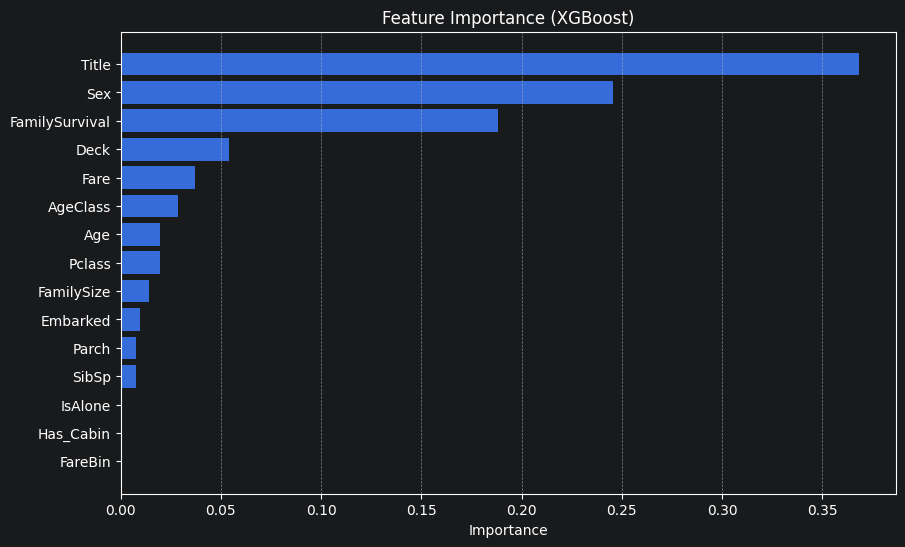

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

model_xgb.fit(X, y)

importance = model_xgb.feature_importances_

feature_importance_df = pd.DataFrame({'feature': features, 'importance': importance}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.gca().invert_yaxis()

plt.xlabel('Importance')
plt.title('Feature Importance (XGBoost)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [100, 150, 200, 300],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X, y)

print("Grid Search best parameters")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_ * 100:.2f}%")

print(grid_search.best_params_)


Grid Search best parameters
Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 150, 'subsample': 0.8}
Best score: 87.99%
{'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 150, 'subsample': 0.8}


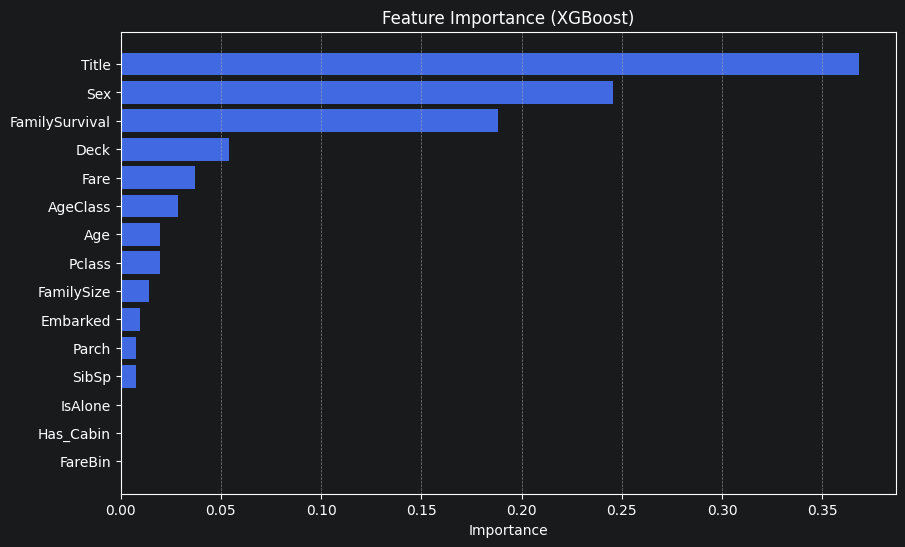

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

model_xgb.fit(X, y)

importance = model_xgb.feature_importances_

feature_importance_best_df = pd.DataFrame({'feature': X.columns, 'importance': importance}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_best_df['ffeature' if 'ffeature' in feature_importance_best_df else 'feature'], feature_importance_best_df['importance'], color='royalblue')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Feature Importance (XGBoost)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [19]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title',
            'FamilySize', 'Deck', 'AgeClass', 'FamilySurvival']

X = train_clean[features]
y = train_clean['Survived']

param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [100, 150, 200, 300],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X, y)

print("Grid Search best parameters")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_ * 100:.2f}%")

print(grid_search.best_params_)

Grid Search best parameters
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 200, 'subsample': 0.8}
Best score: 87.88%
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 200, 'subsample': 0.8}
